<a href="https://colab.research.google.com/github/j019/Practical-Machine-Learning-/blob/main/Day2/Case_Study_Diamonds_csv_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# case study for clustering :: diamonds.csv

- Preprocess the data




In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('diamonds.csv')
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
df.shape

(53940, 10)

In [7]:
df.isna().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [8]:
df.drop_duplicates(inplace=True)
df.shape

(53794, 10)

In [9]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [10]:
df.dtypes

,0
carat,float64
cut,object
color,object
clarity,object
depth,float64
table,float64
price,int64
x,float64
y,float64
z,float64


In [11]:
df.nunique()

,0
carat,273
cut,5
color,7
clarity,8
depth,184
table,127
price,11602
x,554
y,552
z,375


In [12]:
df_ohe = pd.get_dummies(df)
df_ohe.head()

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,True,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,False,True,False,...,False,True,False,False,False,True,False,False,False,False


In [13]:
df_ohe.shape

(53794, 27)

In [14]:
df_ohe.columns

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut_Fair',
       'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_D',
       'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J',
       'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1',
       'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2'],
      dtype='object')

In [15]:
X = df_ohe

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.3, random_state=7)

X_train.shape, X_test.shape

((37655, 27), (16139, 27))

- Find the best K for k means using Lbow method

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertia_values = []
for k in range(2,11):
    mykmeans = KMeans(k,random_state=7)
    mykmeans.fit(X_train)
    inertia_values.append(mykmeans.inertia_)

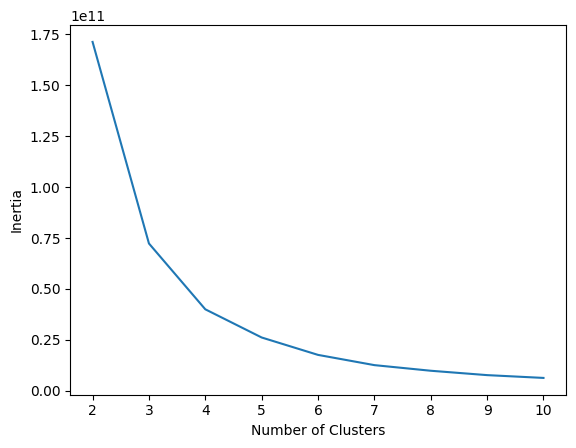

In [21]:
import matplotlib.pyplot as plt
plt.plot(list(range(2,11)), inertia_values) # Elbow means angle close to 90
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [22]:
km = KMeans(n_clusters=3,random_state=7)
km.fit(X_train)

KMeans(n_clusters=3, random_state=7)


- Change K and compare silhoutte score

In [23]:
y_pred = km.predict(X_test)
print(silhouette_score(X_test, y_pred))

0.6630058457592924



- Draw dendrogram on first 500 rows of data, find best K



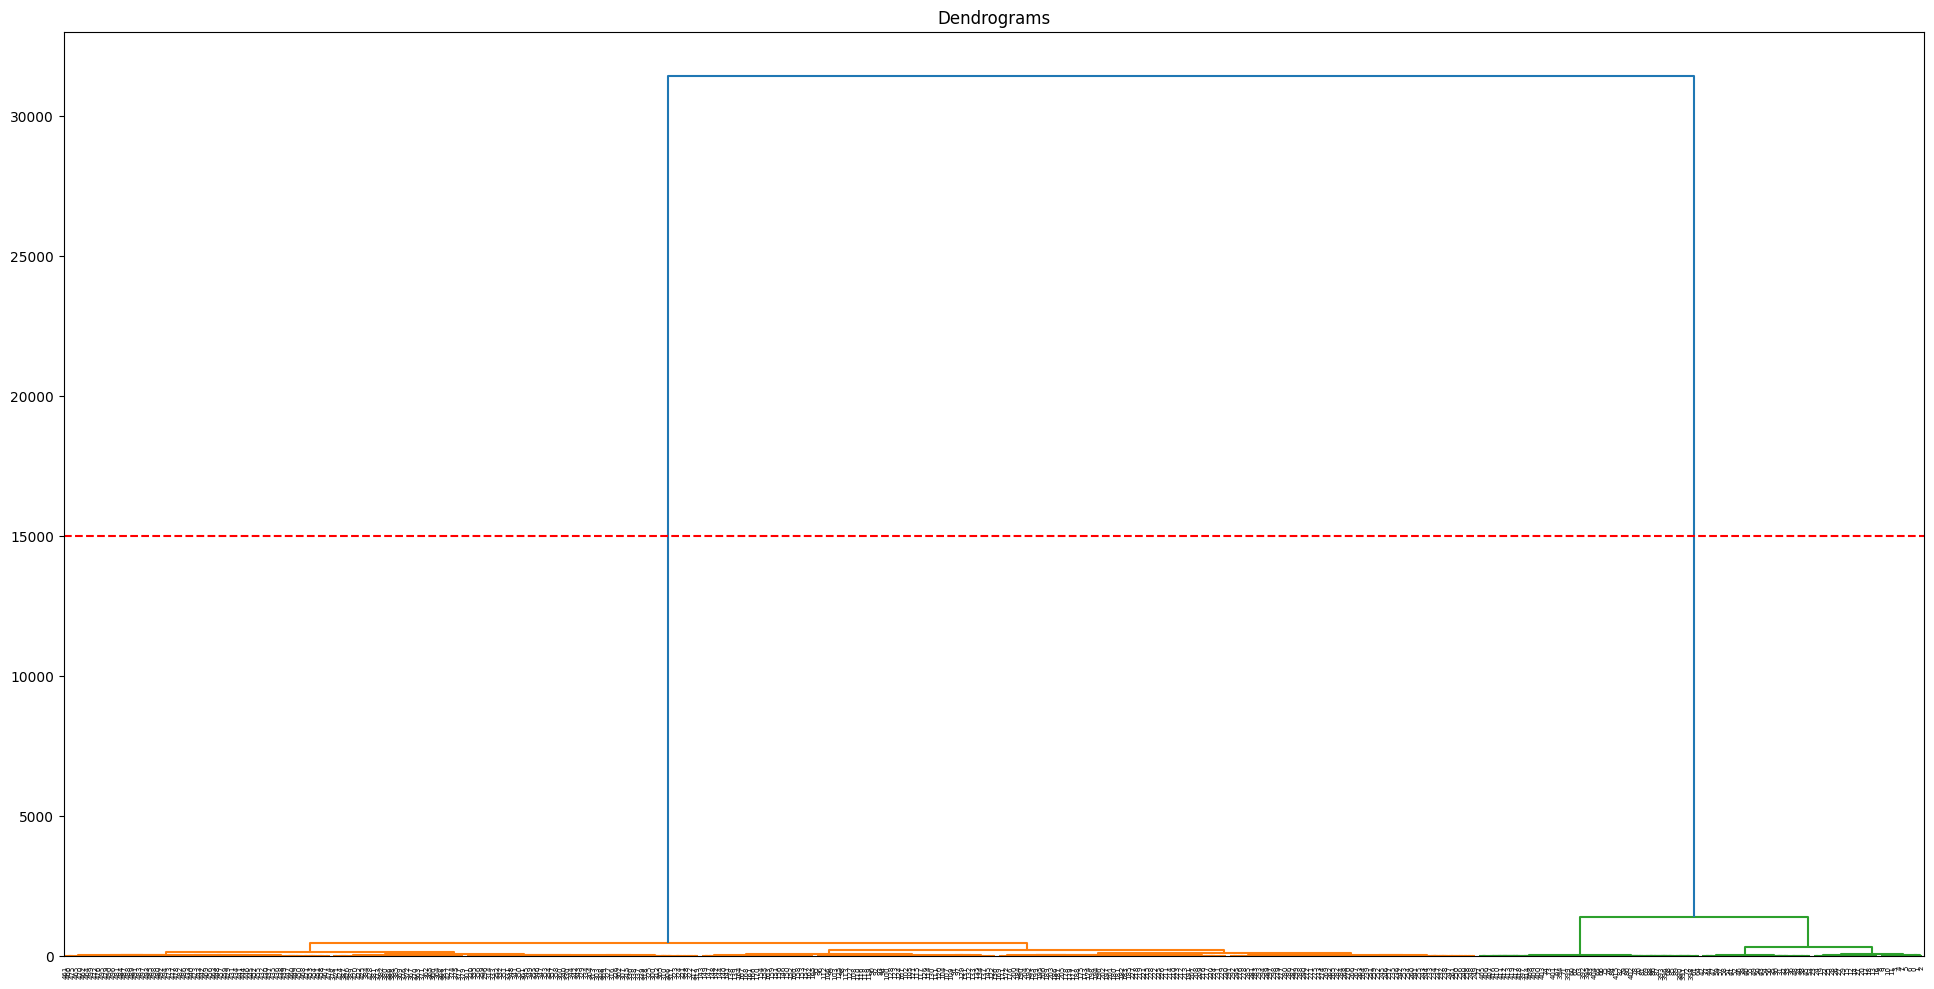

In [28]:
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(24, 12))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X.iloc[:500,:], method='ward'))
plt.axhline(y=15000, color='r', linestyle='--')
plt.xticks(rotation=90)
plt.show()

# here k=2 as we have taken only 500 rows

- Apply agglomerative clustering

- Calculate silhoutte score for KMeans and Agglomarative clustering

- Change the linkage type in agglomarative clustering and compare silhoutte score


In [29]:
from sklearn.cluster import AgglomerativeClustering
# default linkage : 'ward' here we are using 'complete', k=3
ac = AgglomerativeClustering(n_clusters=3,linkage='complete')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train)

In [30]:
print(silhouette_score(X_train, y_pred))

0.6497417528093823


In [31]:
# Single Linkage, k=3
ac = AgglomerativeClustering(n_clusters=3,linkage='single')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train)
print(silhouette_score(X_train, y_pred))

0.1853162959303495


In [34]:
# Average Linkage, k=3
ac = AgglomerativeClustering(n_clusters=3,linkage='average')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train)
print(silhouette_score(X_train, y_pred))

0.6571400712241439


In [32]:
# 'ward' linkage, k=3
ac = AgglomerativeClustering(n_clusters=3)
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train)
print(silhouette_score(X_train, y_pred))

0.6508994453617107


In [33]:
# k=4, 'ward' Linkage
ac = AgglomerativeClustering(n_clusters=4)
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train)
print(silhouette_score(X_train, y_pred))

0.6542773926922777


In [35]:
# Average Linkage, k=4
ac = AgglomerativeClustering(n_clusters=4,linkage='average')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train)
print(silhouette_score(X_train, y_pred))

0.5898597165152226


In [36]:
# Complete Linkage, k=4
ac = AgglomerativeClustering(n_clusters=4,linkage='complete')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train)
print(silhouette_score(X_train, y_pred))

0.6455163110272144


In [37]:
# Single Linkage, k=4
ac = AgglomerativeClustering(n_clusters=4,linkage='single')
#ac.fit(X_train)
y_pred = ac.fit_predict(X_train)
print(silhouette_score(X_train, y_pred))

-0.03129678424783516
